# Real Estate Price Analysis

The real estate dataset used in this assignment contains historical data from certain real estate markets between June 2012 and May 2013. 

It is related to two districts in Taipei City and two districts in New Taipei City. 

<br>

The dataset is composed of 414 records of property sales and the features describe certain aspects of the properties sold. This data is sourced from the UCI machine learning webpage, where this another other datasets are [publicly accessible](https://archive.ics.uci.edu/ml/datasets/Real+estate+valuation+data+set)

The following table provides a summary of each feature in the dataset: 

KATE expects your code to define variables with specific names that correspond to certain things we are interested in.

KATE will run your notebook from top to bottom and check the latest value of those variables, so make sure you don't overwrite them.

* Remember to uncomment the line assigning the variable to your answer and don't change the variable or function names.
* Use copies of the original or previous DataFrames to make sure you do not overwrite them by mistake.

You will find instructions below about how to define each variable.

Once you're happy with your code, upload your notebook to KATE to check your feedback.


| Variable  | Meaning | Type |
| ------------- | ------------- | ------------- |
| X1 Transaction Date|  Month in which the transaction has happened starting counting from the first month of the dataset |  for example 2013.250=2013 March |
| X2 house age | The house age  | Unit (year) |
| X3 distance to the nearest MRT station | The distance to the nearet MRT station | Numerical (meters) |
| X4 number of convenience stores | The number of convenience stores in the living circle on foot | Numerical (integer) | 
| X5 latitude | The geographic coordinate, latitude | numerical (degree)| 
| X6 longitude | The geographic coordinate, longitude | numerical (degree) | 
| Y house price of unit area | Output variable, house price of unit area | numerical (10000 New Taiwan Dolla/Ping, where Ping is a local unit, 1 Ping = 3.3 meter squared)

Having inspected what the features mean, let's begin by importing the libaries needed for this assignment:

In [1]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

## Load the dataset

With these libaries, in particular `pandas`, let's load the `real_estate_valuation_data_set.csv` file, which is located in a folder called `data`, into a DataFrame named `df` using the following code:

In [2]:
df = pd.read_csv('data/real_estate_valuation_data_set.csv')
df.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


## Dataset Preprocessing 

Before proceeding to the analysis, let's first do some preprocessing to clean our data and get a better sense of what it looks like.

<br>

**1. Print the format of your dataframe (number of rows, columns) and, store whether or not the dataframe contains any missing values in a variable called `values_missing`.**

Note that `values_missing` should be a Boolean.

*Hint: you can use two `pandas` methods, [`.isna()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.isna.html) and [`.any()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.any.html) applied to your dataframe to get this information.*

In [23]:
# Your code here 
df.info()
values_missing = df.isna().any().any()
print("Any missing values:", values_missing)


<class 'pandas.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 7 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   X1 transaction date                     414 non-null    float64
 1   X2 house age                            414 non-null    float64
 2   X3 distance to the nearest MRT station  414 non-null    float64
 3   X4 number of convenience stores         414 non-null    int64  
 4   X5 latitude                             414 non-null    float64
 5   X6 longitude                            414 non-null    float64
 6   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 22.8 KB
Any missing values: False


**2. Remove the first column `X1 transaction date`from the dataset and save the newly created dataset into a new variable `df_new`.**

You should also use the `.copy()` method when creating `df_new`.

In [24]:
# Your code here
df_new = df.drop(columns=['X1 transaction date']).copy()

**3.  Plot a histogram of the target variable `Y house price of unit area`.**

This is an important preliminary step to help us understand the distribution of the target variable. For example you can see if it resembles a normal distribution, or if it is skewed in some way, and adjust your model accordingly.

Assign the output to a variable called `hist_y`.

*Hint: use the `.hist()` method on a `pandas` `Series`*

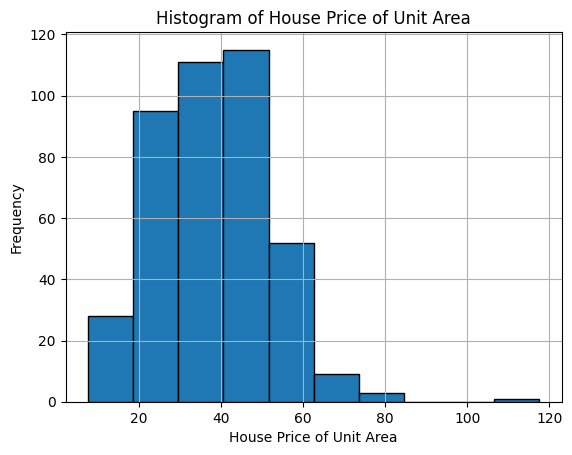

In [25]:
# We create a new figure to make sure other figures in the notebook don't get modified
plt.figure()
# Your code here
hist_y = df_new['Y house price of unit area'].hist(bins=10, edgecolor='black')
plt.xlabel('House Price of Unit Area')
plt.ylabel('Frequency')
plt.title('Histogram of House Price of Unit Area')
plt.show()


**4. Plot histograms of all of the remaining input variables in your dataframe.**

Note that we have already dropped the `X1 transaction date` variable, which leaves us with five variables (`X2` through `X6`).

<br>

To create these plots:
  - Use the `fig, ax = plt.subplots(figsize=(10,25), dpi=50)` to create your figure and axes
  - Filter down `df_new` to the relevant columns and call `.hist()` passing in:
     - `ax=ax`
     - `layout=(5,1)`
     - and the column names, ordered from `X2` to `X6`

Assign the output of `.hist()` to a variable called `hist_per_input`.

/var/folders/qx/l96sp59j46316s33f680yyr80000gp/T/ipykernel_21142/3559817433.py:13: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  hist_per_input = df_filtered.hist(ax=ax, layout=(5, 1), bins=10)


<Figure size 640x480 with 0 Axes>

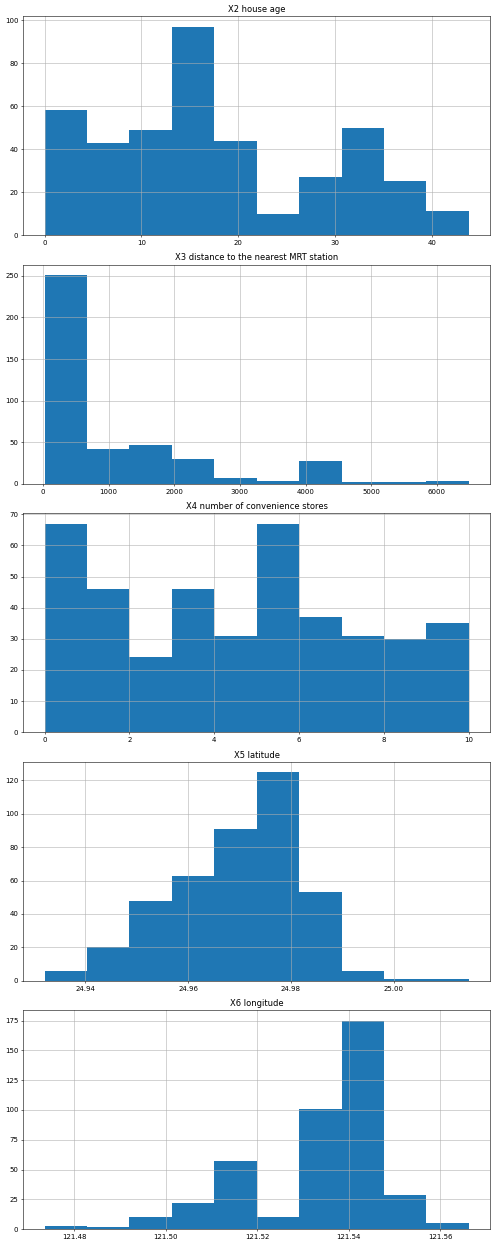

In [26]:
# We create a new figure to make sure other figures in the notebook don't get modified
plt.figure()
# Your code here
columns_of_interest = [
    'X2 house age', 
    'X3 distance to the nearest MRT station', 
    'X4 number of convenience stores', 
    'X5 latitude', 
    'X6 longitude'
]
df_filtered = df_new[columns_of_interest]
fig, ax = plt.subplots(figsize=(10, 25), dpi=50)
hist_per_input = df_filtered.hist(ax=ax, layout=(5, 1), bins=10)
plt.tight_layout()


**5. Obtain the mean and median of the variable outcome `Y house price of unit area`.**

Store the results in variables called `mean` and `median`. 


In [9]:
# Your code here
house_price_mean = df_new['Y house price of unit area'].mean()
house_price_median = df_new['Y house price of unit area'].median()


**6. Scale all the dataframe columns but `Y house price of unit area`, that is our output. For scaling use the min-max normalization. Save the newly scaled dataframe into a new dataframe named `df_new_scaled`.**

The min max scaling formula (considering you want to scale between 0 and 1) is as follows: 

```Python
df_new_scaled = (originalDataframe - min_val_originalDF) / (max_val_originalDF - min_val_originalDF) 
```

In [27]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
columns_to_scale = df_new.drop(columns=['Y house price of unit area'])
scaled_data = scaler.fit_transform(columns_to_scale)
df_scaled = pd.DataFrame(scaled_data, columns=columns_to_scale.columns)
df_new_scaled = pd.concat([df_scaled, df_new['Y house price of unit area'].reset_index(drop=True)], axis=1)
df_new_scaled.head()

,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,0.730594,0.009513,1.0,0.616941,0.719323,37.9
1,0.445205,0.043809,0.9,0.584949,0.711451,42.2
2,0.303653,0.083315,0.5,0.671231,0.758896,47.3
3,0.303653,0.083315,0.5,0.671231,0.758896,54.8
4,0.114155,0.056799,0.5,0.573194,0.743153,43.1


## Fitting a linear regression model

**7. Create a linear regression model and fit it to your data.**

First, create two variables: `X1` and `y1` whcih contain the input features and target variable, respectively.

Next, create linear regression model called `reg1` and fit it on `X1` and `y1`

*Hint: use the `sklearn.linear_model import LinearRegression` to perform linear regression.*

In [28]:
from sklearn.linear_model import LinearRegression
X1 = df_new_scaled.drop(columns=['Y house price of unit area'])
y1 = df_new_scaled['Y house price of unit area']
reg1 = LinearRegression()
reg1.fit(X1, y1)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**8. Print the value of the $R^2$ coefficient of the fitted linear regression and save it in a variable `reg1_R2`.**

The $R^2$ (pronounced "r-squared") coefficient is useful to understand how well your model has worked: the closer to 1, the better your model has worked!

To calculate the $R^2$, you can use the [`.score()`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) method.

Store the coefficient in a variable called `reg1_R2`. 

In [29]:
# Your code here
reg1_R2 = reg1.score(X1, y1)
print("R^2 coefficient (reg1):", reg1_R2)


R^2 coefficient (reg1): 0.5711617064827432


**9. Store the coefficients of the regression model `reg1` in a variable called `coefficients`**

Think about what this implies: 
 - Which features have a positive relationship with `Y house price of unit area`? 
 - Which ones are negative?

In [30]:
# Your code here
coefficients = reg1.coef_
print("Coefficients (reg1):", coefficients)



Coefficients (reg1): [-11.77855728 -27.53346917  11.63020477  19.6205486   -0.72387769]


**10. Now create a new linear regression model using only the variables: `X2 house age`, `X5 latitude`,  and `X6 longitude`. Save the model in a variable called `reg2` and fit it to your new data.**

Before calling `.fit()` you should create two new dataframes for this new model:
 - `X2` which contains the input variables of interest
 - `y2` which contains the target variable

In [31]:
# Your code here
X2 = df_new_scaled[['X2 house age', 'X5 latitude', 'X6 longitude']]
y2 = df_new_scaled['Y house price of unit area']
reg2 = LinearRegression()
reg2.fit(X2, y2)
coefficients_reg2 = reg2.coef_
print("Coefficients (reg2):", coefficients_reg2)



Coefficients (reg2): [-11.34007145  37.779205    27.9836173 ]


**11. Now calculate the $R^2$ score for your new model.**

Store the score in a variable called `reg2_R2`.

Which model works best?

In [32]:
# Your code here
reg2_R2 = reg2.score(X2, y2)
print("R^2 coefficient (reg2):", reg2_R2)

R^2 coefficient (reg2): 0.45186380118830627


**12. Divide the dataset into train and test set.**

Use the `train_test_split` from the `sklearn.model_selection` package to split the `df_new_scaled` dataframe into $4$ subsets: 
 - `X_train`
 - `X_test`
 - `y_train`
 - `y_test`

In doing so, specify the test size to be `0.25` and set the `random_state=101` for reproducibility.

In [33]:
from sklearn.model_selection import train_test_split 
X = df_new_scaled.drop(columns=['Y house price of unit area'])
y = df_new_scaled['Y house price of unit area']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)

**13. Create and fit a linear regression model to the training set, using all of the variables to predict `Y house price of unit area`.**  

Assign your model to a variable called `reg3`.

*Hint: use the `.fit()` method.*

In [35]:
# Your code here
reg3 = LinearRegression()
reg3.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**14. Use the model to generate predictions on `X_test`.**

Save the predicted variables into a variable called `y_pred` 

In [36]:
# Your code here
y_pred = reg3.predict(X_test)
print("Predictions:", y_pred)


Predictions: [14.14137085  8.36465066 25.19738842 48.42975086 30.76133955 37.07387214
 38.03769435 40.79712791 46.63258105 40.38117096 43.95009415 33.29448044
 38.74602292 37.88407162 46.59321099 48.95154389 38.10242705 46.04251048
 50.64185599 48.15430103 40.03791589 53.20993074 47.2986705  37.21429327
 31.48135033 50.64873743 38.98248516 48.7565108  45.84971619 38.60520027
 50.37790614 42.22752003 43.40049023 45.76650805 45.23115427  6.85223858
 37.63189154 38.9237537   6.79431776 55.30768348 31.01074933 47.72570056
 23.51829187 48.64911605 43.18953541 50.93466142 40.6180904  36.66902405
 45.29587095 36.12525747 47.15800785 35.9437944  42.05375757 13.98418501
 38.61075596 47.95920461 43.24469128 46.13816375 43.84562497 40.33287914
 32.73079023 44.12472669 42.1406388  42.48036018 52.66944882 42.81340229
 24.79229515 48.81481004 30.51331365 39.19045155 44.10241351 49.19993446
 13.59150769 34.50446595 14.08752382 43.86379132 32.83713292 44.5838805
 42.64331822 10.58789095 46.17204669 36

In [37]:
import pickle
pickled = pickle.dumps(y_pred, 0)

In [38]:
pickled

b'cnumpy._core.multiarray\n_reconstruct\np0\n(cnumpy\nndarray\np1\n(I0\ntp2\nc_codecs\nencode\np3\n(Vb\np4\nVlatin1\np5\ntp6\nRp7\ntp8\nRp9\n(I1\n(I104\ntp10\ncnumpy\ndtype\np11\n(Vf8\np12\nI00\nI01\ntp13\nRp14\n(I3\nV<\np15\nNNNI-1\nI-1\nI0\ntp16\nbI00\ng3\n(VJL~\xc2aH,@\\u000a-\xe6}\xb3\xba @~\x1d3\x0c\x8829@\xf8;\x8b\x13\x027H@\xfe\x81\x02&\xe7\xc2>@\xaa\xc6d\xa4t\x89B@W\xe7#+\xd3\x04C@.\x91\x99I\x08fD@y\x0cmj\xf8PG@j\x98\xcc5\xca0D@\xe0\x99k\xaf\x9c\xf9E@\x91\xed\xfe\x88\xb1\xa5@@E"\xd1\xad}_C@\xaf\x13IB)\xf1B@hg\x7fV\xeeKG@\x92{\xb30\xccyH@\xc82hT\x1c\\u000dC@\xda\x9d\xbf\xfbp\x05G@\xec\xefEV(RI@\xcb\xb9\xda"\xc0\x13H@o\x13\x8dm\xda\x04D@Es\xb7\x02\xdf\x9aJ@\x98f\xbb\xd5:\xa6G@(\xfd=\xf6m\x9bB@%\xefk\xc69{?@\xc4\x9a\x01\xd4\tSI@\xfcO\xd7\x12\xc2}C@X\xb6\x8bX\xd5`H@\x85\x81\x07\x80\xc3\xecF@x\x11\xde3wMC@\xed\xf1\x80:_0I@\xf8\xb9b`\x1f\x1dE@NP\x8aCC\xb3E@f3\x96\xef\x1c\xe2F@p\xaf\x94v\x96\x9dF@P/\xf2:\xb1h\x1b@BKu\xd2\xe1\xd0B@o\xc9\xb4\x8f=vC@\xb4\xa2b\xa2a-\x1b@\xa9\xd5\x10,b\xa7

Once you have generated these predictions, uncomment the cell below to check out the accuracy score of your model. 

Think about what this metric [means](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html). 
  - Is this a good model? 
  - Is mean squared error a good metric? 
  - How does this compare to $R^2$?

In [39]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_pred, y_test)

44.176481796336766